<a href="https://colab.research.google.com/github/arulmurugan-dev/opencv-bootcamp/blob/main/Gaussian%20Vs%20Laplacian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

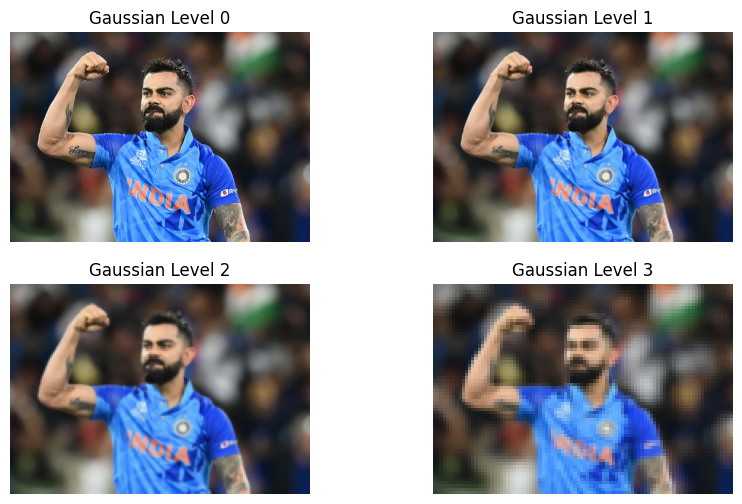

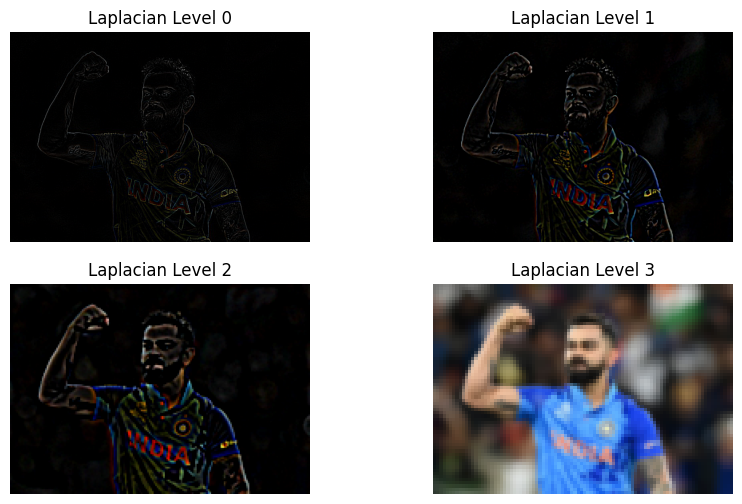

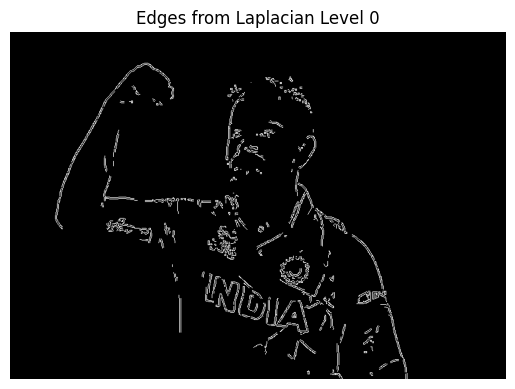

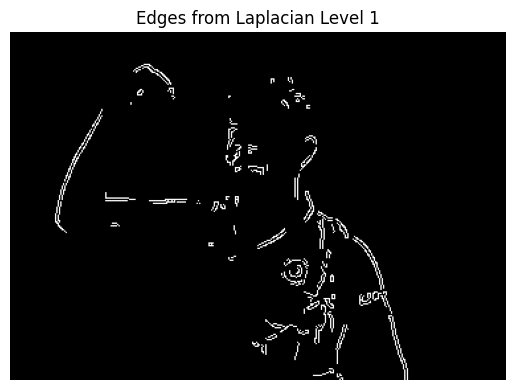

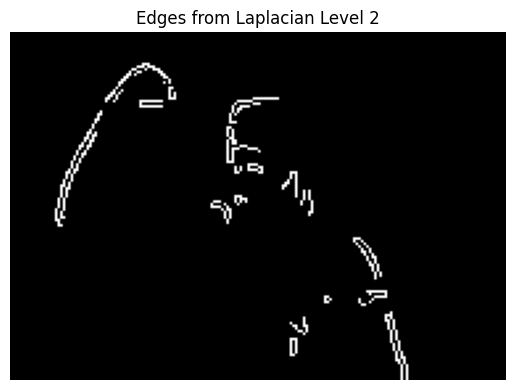

In [21]:

import cv2
import matplotlib.pyplot as plt

# Read image
img = cv2.imread("kohli231007.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ----------------------------
# Gaussian Pyramid
# ----------------------------
G = [img]

for i in range(3):   # number of levels
    G.append(cv2.pyrDown(G[i]))

# Display Gaussian Pyramid
plt.figure(figsize=(10,6))
for i in range(len(G)):
    plt.subplot(2,2,i+1)
    plt.imshow(G[i])
    plt.title(f"Gaussian Level {i}")
    plt.axis("off")
plt.show()


# ----------------------------
# Laplacian Pyramid
# ----------------------------
L = []

for i in range(len(G)-1):
    expanded = cv2.pyrUp(G[i+1])

    # resize to match size
    expanded = cv2.resize(expanded, (G[i].shape[1], G[i].shape[0]))

    laplacian = cv2.subtract(G[i], expanded)
    L.append(laplacian)

# last level added
L.append(G[-1])

# Display Laplacian Pyramid
plt.figure(figsize=(10,6))
for i in range(len(L)):
    plt.subplot(2,2,i+1)
    plt.imshow(cv2.normalize(L[i], None, 0, 255, cv2.NORM_MINMAX))
    plt.title(f"Laplacian Level {i}")
    plt.axis("off")
plt.show()


# ----------------------------
# Edge Detection Comparison
# ----------------------------
for i, im in enumerate(L[:-1]):
    gray = cv2.cvtColor(im, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 100, 200)

    plt.figure()
    plt.imshow(edges, cmap='gray')
    plt.title(f"Edges from Laplacian Level {i}")
    plt.axis("off")
    plt.show()

In [20]:

from google.colab import files
uploaded = files.upload()

Saving kohli231007.jpg to kohli231007.jpg
